# Question1

In [60]:
# Importing necessary libraries
# General Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# ML library
from sklearn import model_selection
from sklearn import linear_model
from sklearn import metrics
from sklearn import linear_model


from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, auc, recall_score,f1_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

### EDA Steps

In [41]:
metric_table = pd.DataFrame()
classification_algorithms = {
    'Logistic-Regression': LogisticRegression(multi_class='auto', random_state=42, max_iter=2000),
    'SVC-Linear': SVC(kernel='linear', probability=True, random_state=42),
    'SVC-RBF': SVC(kernel='rbf', probability=True, random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'KNeighbors': KNeighborsClassifier()
}


In [58]:
random_state = 42
max_pc_bars = 50 # how many PCs to show as bars (for readability)
pca_for_tsne_n_components = 50 # reduce with PCA before t-SNE (speed & noise reduction)
tsne_perplexity = 30
tsne_n_iter = 500

In [51]:
# ...existing code...
# Load the dataset
df = pd.read_csv("image-data-ePGD-endsem.csv")

rows, columns = df.shape
print("Shape of the original dataset:")
print(f'No. of rows: {rows}')
print(f'No. of columns: {columns}')
# How many rows and how many columns have missing data?
cols_with_missing_data = df.isnull().any().sum()
print(f'No. of columns with missing data: {cols_with_missing_data}')

rows_with_missing_data = df.isnull().any(axis=1).sum()
print(f'No. of rows with missing data: {rows_with_missing_data}')
print(f'%. of rows with missing data: {(rows_with_missing_data / rows) * 100:.2f}%')

# Remove rows where any feature column (c1 to c135) is missing (NaN)
feature_cols = [f'c{i}' for i in range(1, 136)]
df = df.dropna(subset=feature_cols)

print("Shape of the nal dataset: after removing rows with missing feature data")
rows, columns = df.shape
print(f'No. of rows: {rows}')
print(f'No. of columns: {columns}')

# Extract features c1 to c135 and label into a new DataFrame
df_features = df[feature_cols + ['label']].copy()

print("Shape:", df_features.shape)
print(df_features.head(2))
# ...existing code...

Shape of the original dataset:
No. of rows: 5010
No. of columns: 140
No. of columns with missing data: 18
No. of rows with missing data: 10
%. of rows with missing data: 0.20%
Shape of the nal dataset: after removing rows with missing feature data
No. of rows: 5000
No. of columns: 140
Shape: (5000, 136)
         c1      c2        c3        c4        c5        c6        c7   c8  \
0  0.001067  0.0116  0.038667  0.064400  0.356800  0.499600  0.027867  0.0   
1  0.000133  0.2368  0.419067  0.112267  0.031467  0.083333  0.116933  0.0   

         c9       c10  ...      c127        c128      c129        c130  \
0  0.002267  0.019733  ...  0.181895  108.658800  6.479477  890.007871   
1  0.000000  0.005867  ...  0.362944  110.399333  7.022868  704.594772   

          c131     c132         c133         c134      c135  label  
0  12778.19310  1091397  3573669.586  3101389.448  0.867844      1  
1  10415.92729   849863  3445633.368  1838827.420  0.533669      1  

[2 rows x 136 columns]


------------------------------------------------
EDA step 1: Checking if any data has nan or missing values
Reason for this step: we need to remove the feaures 
Observa􀆟on and analysis:
Ac􀆟ons to be taken (if any):
Remarks

### we removed some of the feature as the date is not that significant to be removed and will not impact the model

In [43]:
# Group image data based on image_filename and get unique set as dictionary

unique_images = df['image_filename'].unique()

# Create a dictionary: key = image_filename, value = DataFrame of rows for that image
image_groups = {img: df[df['image_filename'] == img].copy() for img in unique_images}

print(f"Total unique images: {len(unique_images)}")
print("Example keys:", list(image_groups.keys())[:5])
# ...existing code...

Total unique images: 465
Example keys: ['IMG_20250705_121136381~2.jpg', 'CIMG0113.JPG', 'IMG_3416.JPG', 'CIMG0217.JPG', 'CIMG0063.JPG']


### There are total unique 465 images into the dataset

Total unique images: 465
Example image name: IMG_20250705_121136381~2.jpg


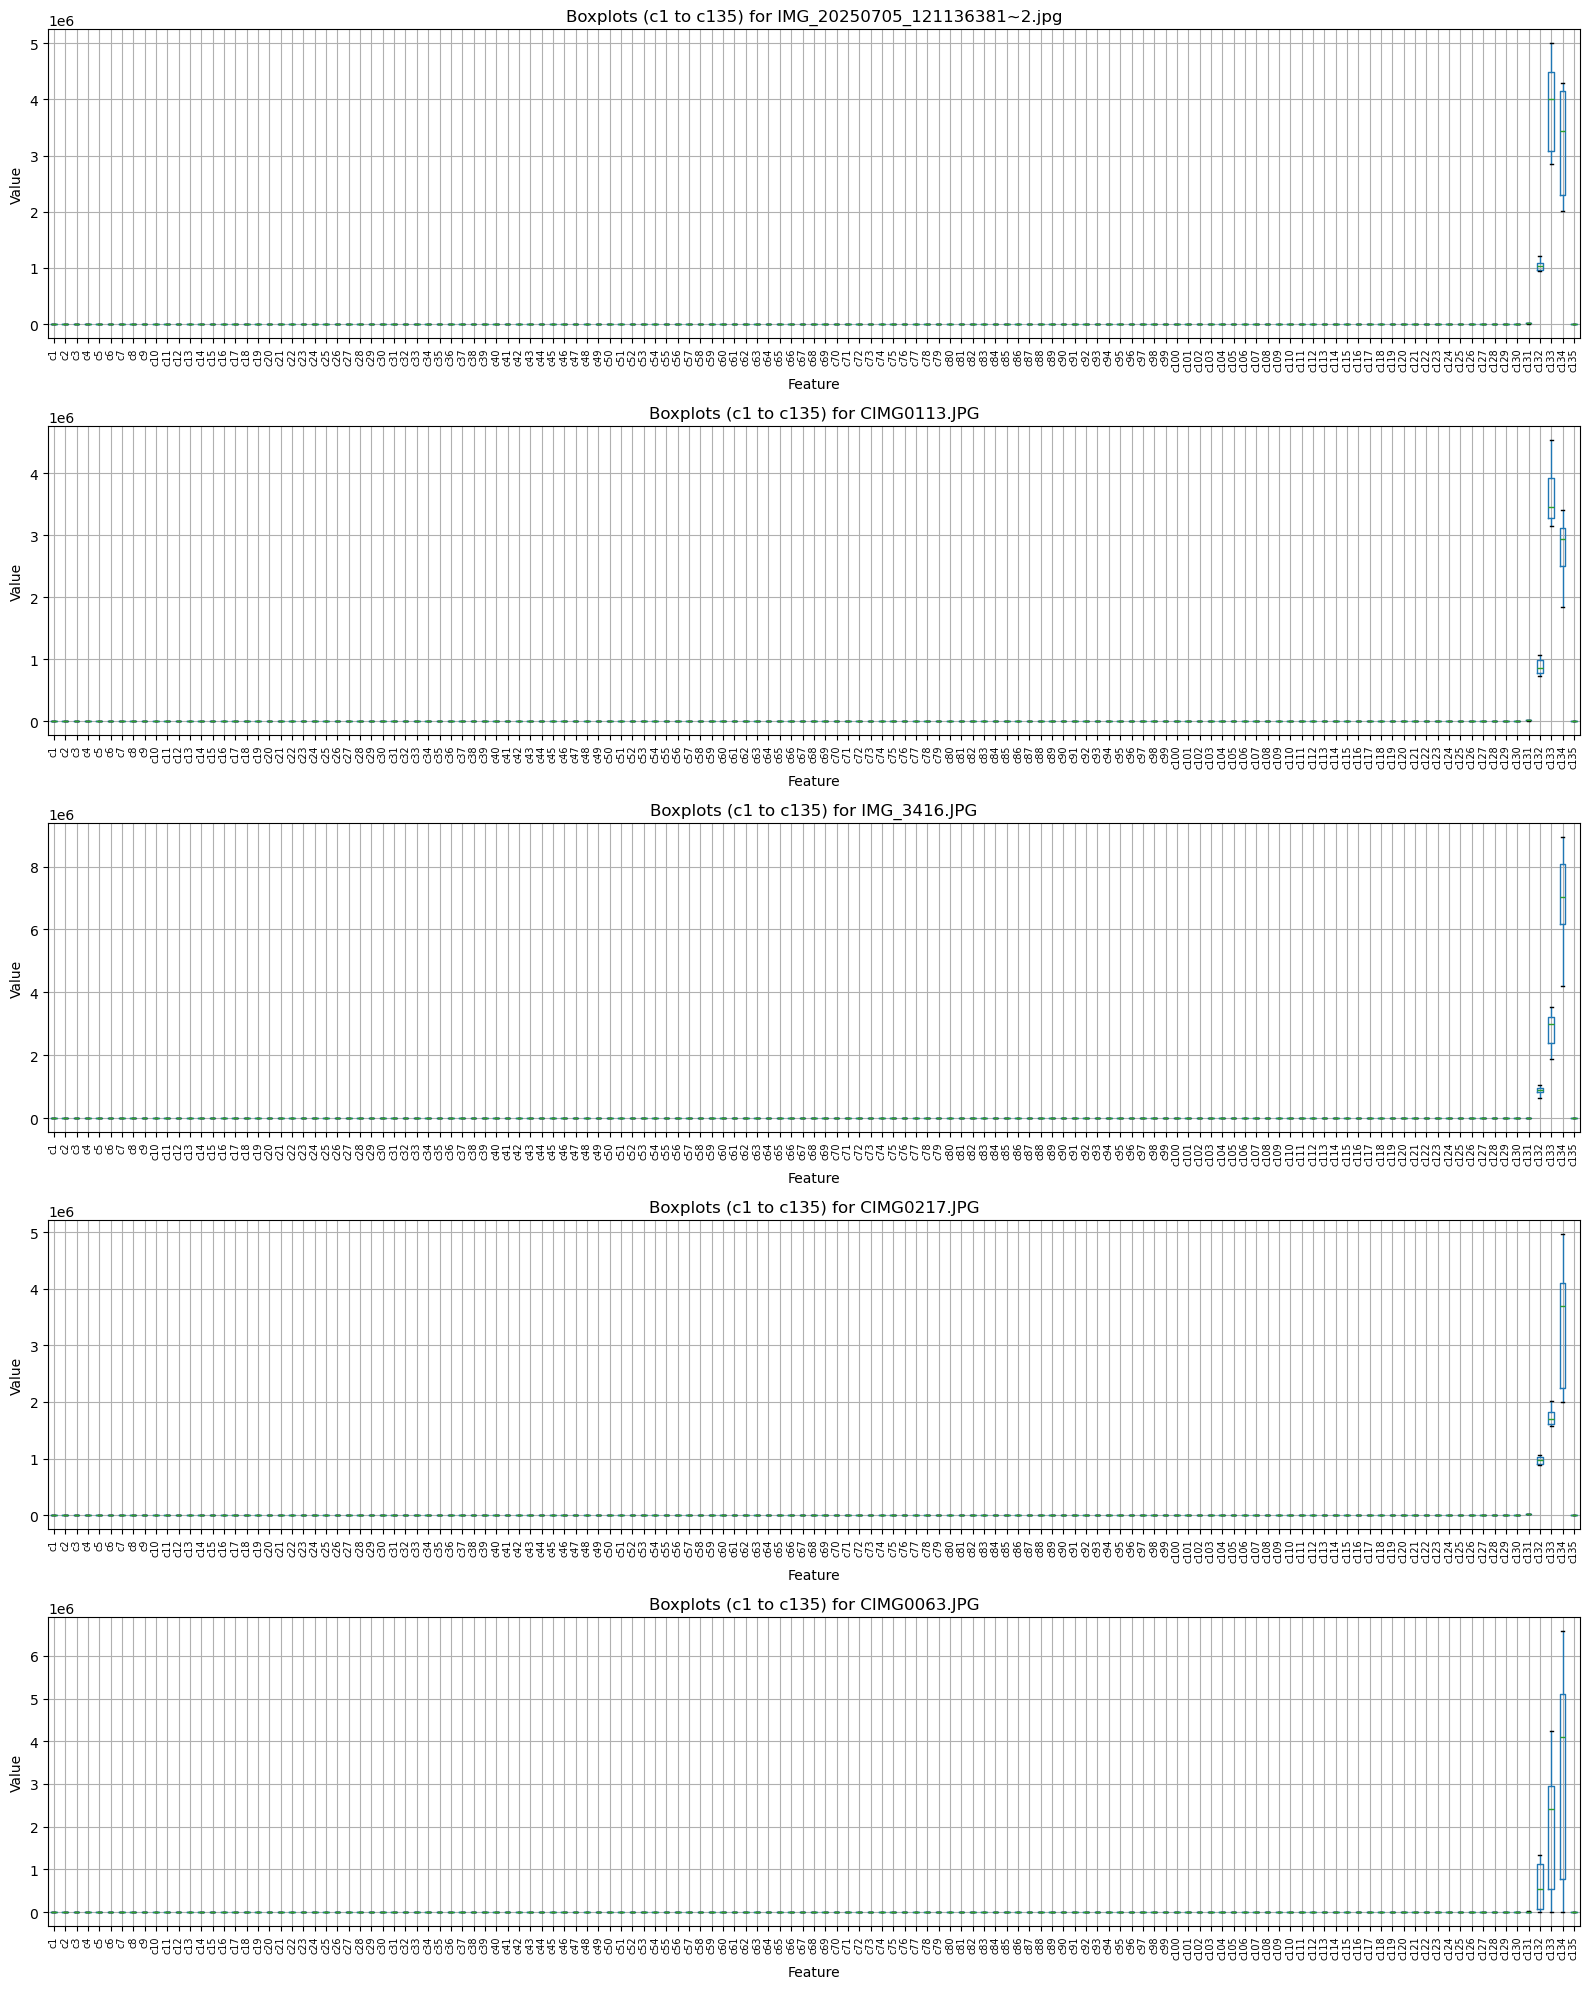

In [44]:
# ...existing code...
# Load the dataset
df = pd.read_csv("image-data-ePGD-endsem.csv")

# Group data per image with its corresponding feature variables (c1 to c135)
feature_cols = [f'c{i}' for i in range(1, 136)]
grouped_images = {img: df[df['image_filename'] == img][feature_cols + ['label']].copy() for img in df['image_filename'].unique()}

print(f"Total unique images: {len(grouped_images)}")
print("Example image name:", list(grouped_images.keys())[0])
# print("Example grouped DataFrame:\n", grouped_images[list(grouped_images.keys())[0]].head(2))

num_images = 5
selected_imgs = list(grouped_images.keys())[:num_images]

fig, axes = plt.subplots(num_images, figsize=(16, 4 * num_images))

for idx, img_name in enumerate(selected_imgs):
    img_df = grouped_images[img_name]
    # Boxplot for all feature vectors
    img_df[feature_cols].boxplot(ax=axes[idx], showfliers=False)
    axes[idx].set_title(f'Boxplots (c1 to c135) for {img_name}')
    axes[idx].set_xlabel('Feature')
    axes[idx].set_ylabel('Value')
    axes[idx].tick_params(axis='x', labelrotation=90, labelsize=7)

plt.tight_layout()
plt.show()
# ...existing code...


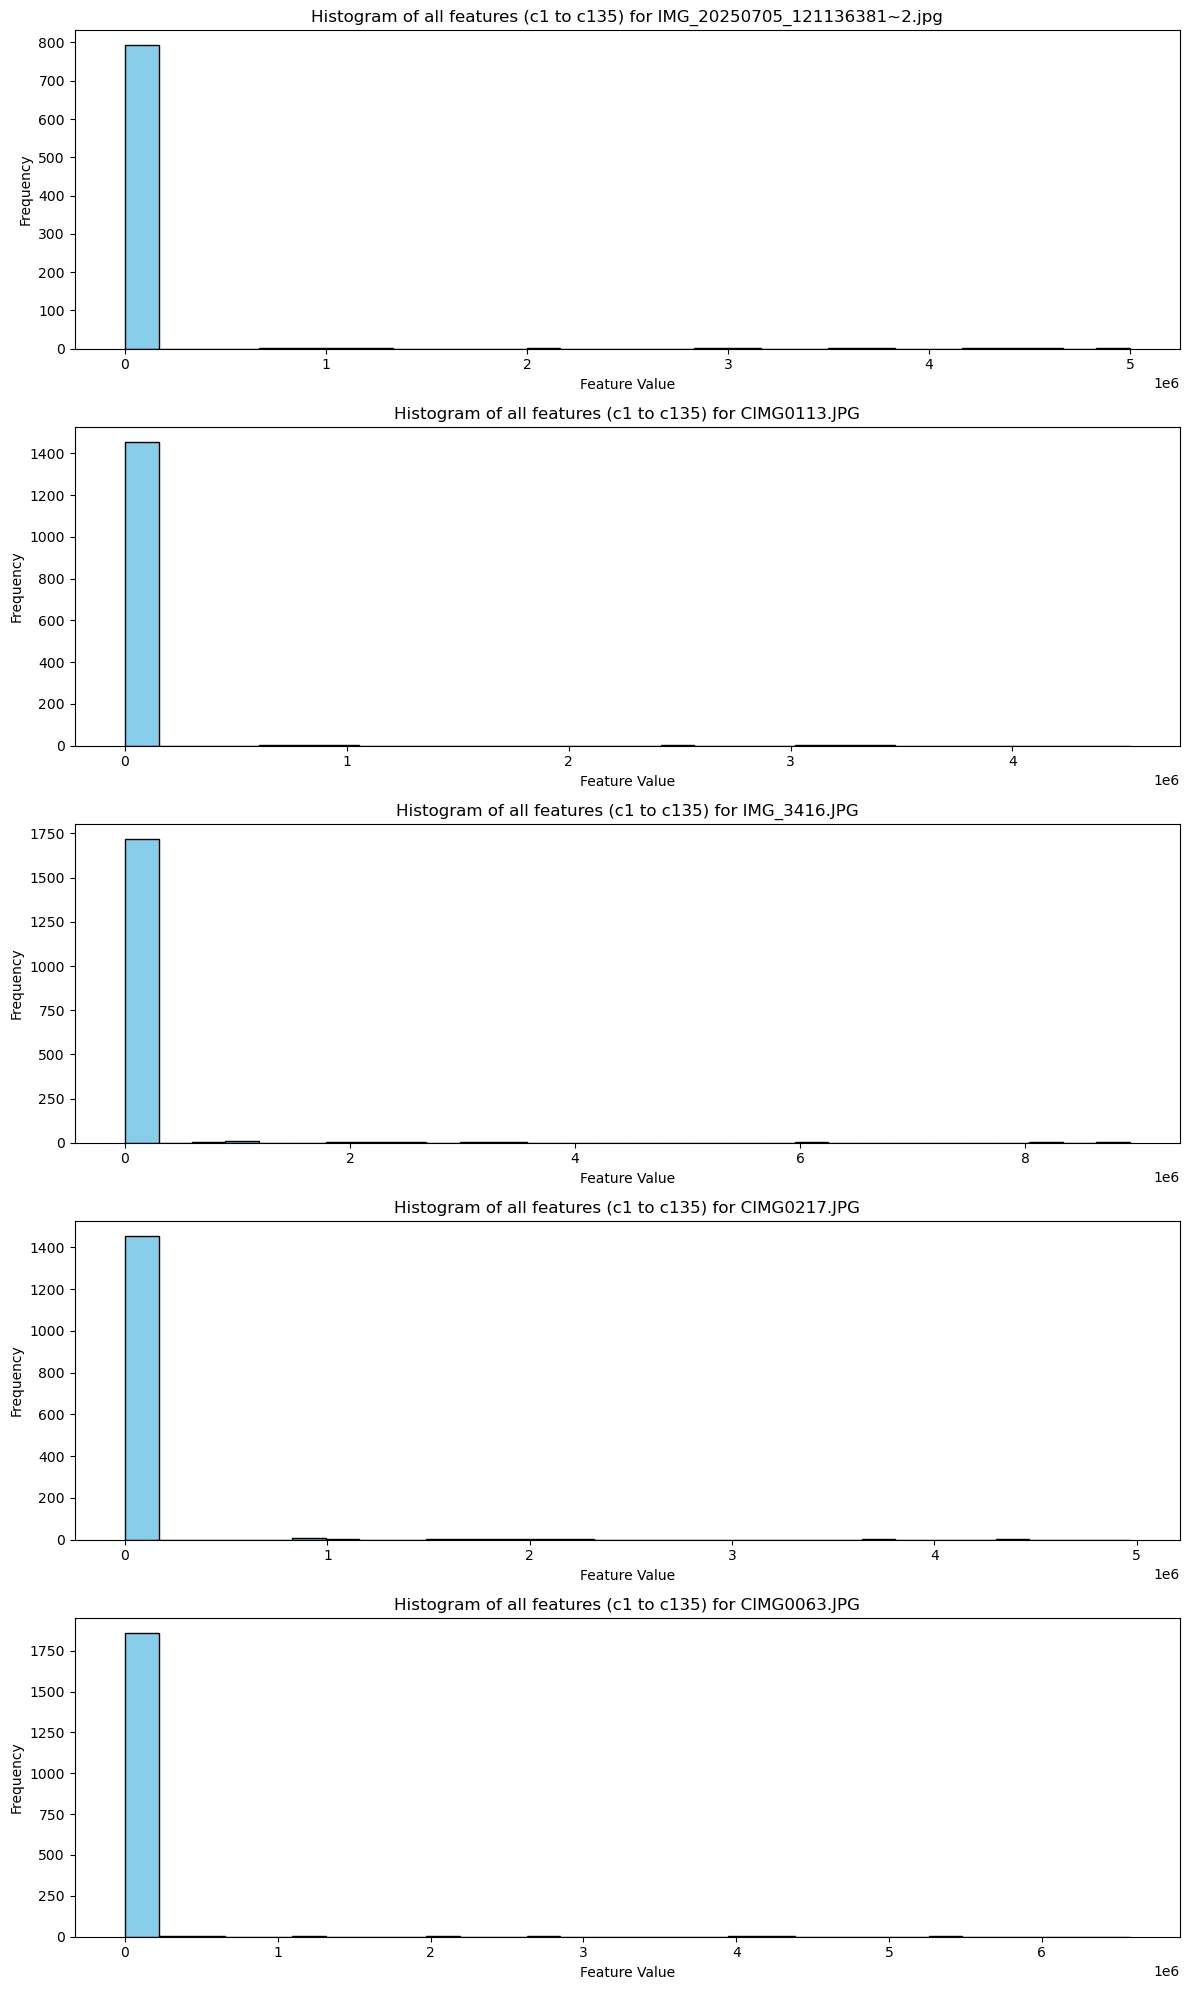

In [45]:
# ...existing code...
# Plot histogram of all features (c1 to c135) for the first 5 grouped images with subplotting

num_images = 5
selected_imgs = list(grouped_images.keys())[:num_images]

fig, axes = plt.subplots(num_images, 1, figsize=(12, 4 * num_images))

for idx, img_name in enumerate(selected_imgs):
    img_df = grouped_images[img_name]
    all_feature_values = img_df[feature_cols].values.flatten()
    axes[idx].hist(pd.Series(all_feature_values).dropna(), bins=30, color='skyblue', edgecolor='black')
    axes[idx].set_title(f'Histogram of all features (c1 to c135) for {img_name}')
    axes[idx].set_xlabel('Feature Value')
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()
# ...existing code...

### Above analysis we see that

as per the above data we can see that the data of one of the image has the scaling problem and we need the data to be subjected to scaling

We would also require to reduce the number of feature and subject to dimentionality reduction 

PCA for IMG_20250705_121136381~2.jpg:
Original shape: (5000, 136)
Scaled shape: (5000, 136)
PCA shape: (5000, 21)
Explained variance ratio: [0.22214138 0.17197476 0.12356099 0.07690376 0.06369794 0.03770101
 0.03134964 0.0278346  0.021064   0.01855008 0.01436298 0.01416615
 0.01244118 0.01115996 0.01081225 0.00964677 0.00877722 0.00808831
 0.00765894 0.00721426 0.00669557]
Number of components: 21


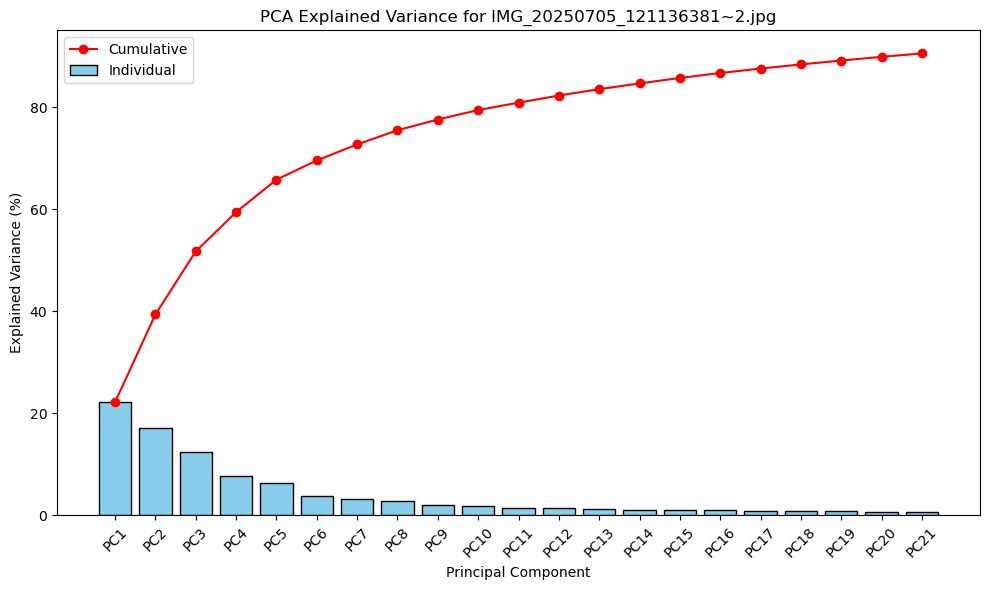

In [ ]:
# ...existing code...
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

# Scale and apply PCA for each grouped image
scaled_pca_images = {}

for img_name, img_df in grouped_images.items():
    # Only use feature columns for scaling and PCA
    X = df_features.values

    # Min-Max Scaling
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    # PCA (keep enough components to explain ~95% variance or set n_components as needed)
    pca = PCA(n_components=0.90, svd_solver='full')
    X_pca = pca.fit_transform(X_scaled)
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = explained_variance.cumsum()
    # Store results in dictionary
    scaled_pca_images[img_name] = {
        'scaled': X_scaled,
        'pca': X_pca,
        'explained_variance_ratio': pca.explained_variance_ratio_,
        'n_components': pca.n_components_
    }
    
    # Example print for first image
    if img_name == list(grouped_images.keys())[0]:
        print(f"PCA for {img_name}:")
        print(f"Original shape: {X.shape}")
        print(f"Scaled shape: {X_scaled.shape}")
        print(f"PCA shape: {X_pca.shape}")
        print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
        print(f"Number of components: {pca.n_components_}")
        
        plt.figure(figsize=(10, 6))
        pc_labels = [f"PC{i+1}" for i in range(len(explained_variance))]
        plt.bar(pc_labels, explained_variance * 100, color='skyblue', edgecolor='black', label='Individual')
        plt.plot(pc_labels, cumulative_variance * 100, color='red', marker='o', label='Cumulative')
        plt.xlabel('Principal Component')
        plt.ylabel('Explained Variance (%)')
        plt.title(f'PCA Explained Variance for {img_name}')
        plt.xticks(rotation=45)
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        axes[idx].scatter(X_pca[:, 0], X_pca[:, 1], c='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].set_xlabel('PC1')
        axes[idx].set_ylabel('PC2')
        axes[idx].set_title(f'PC1 vs PC2 for {img_name}')

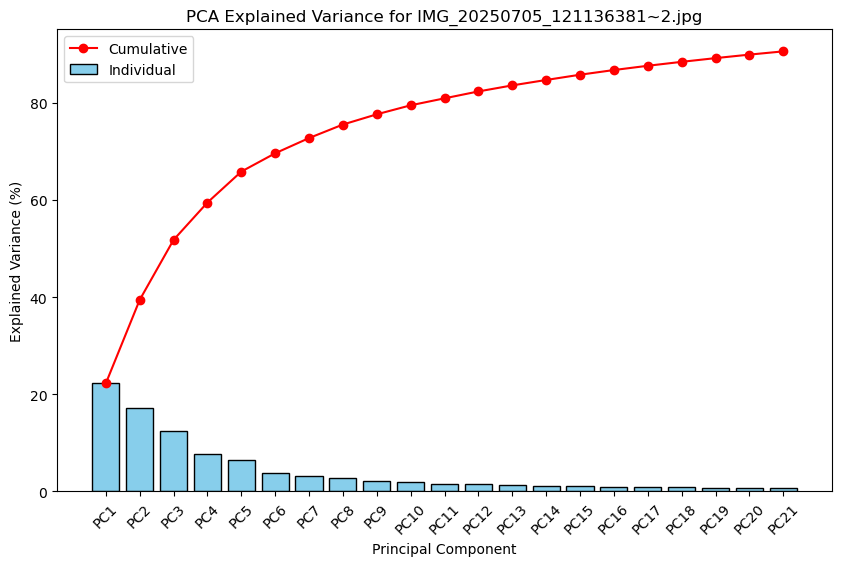

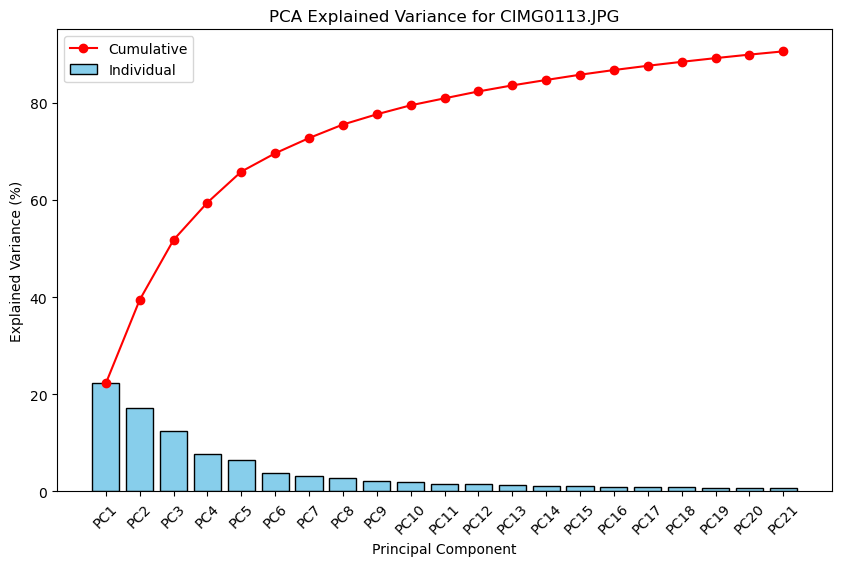

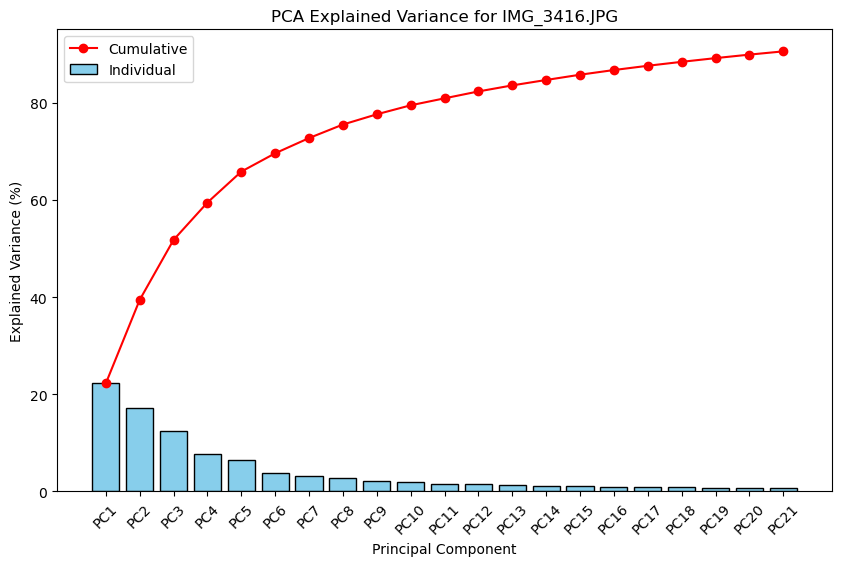

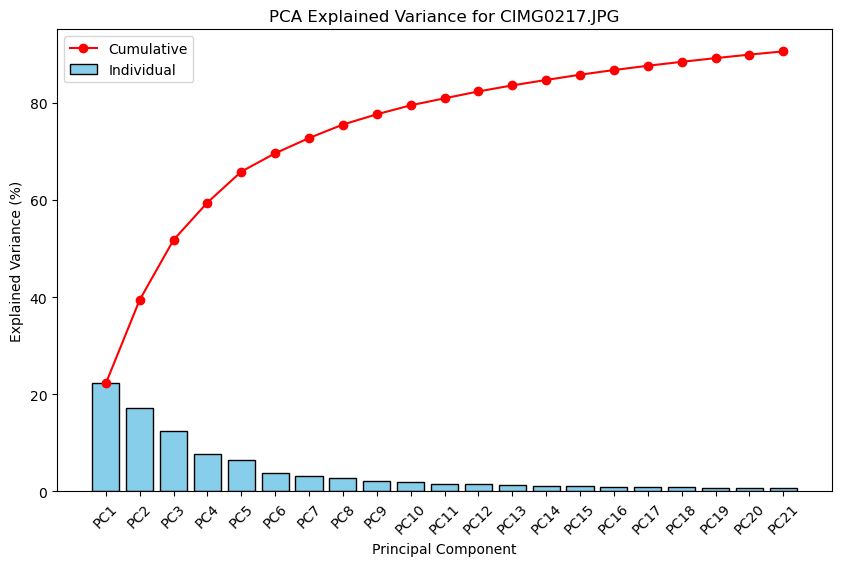

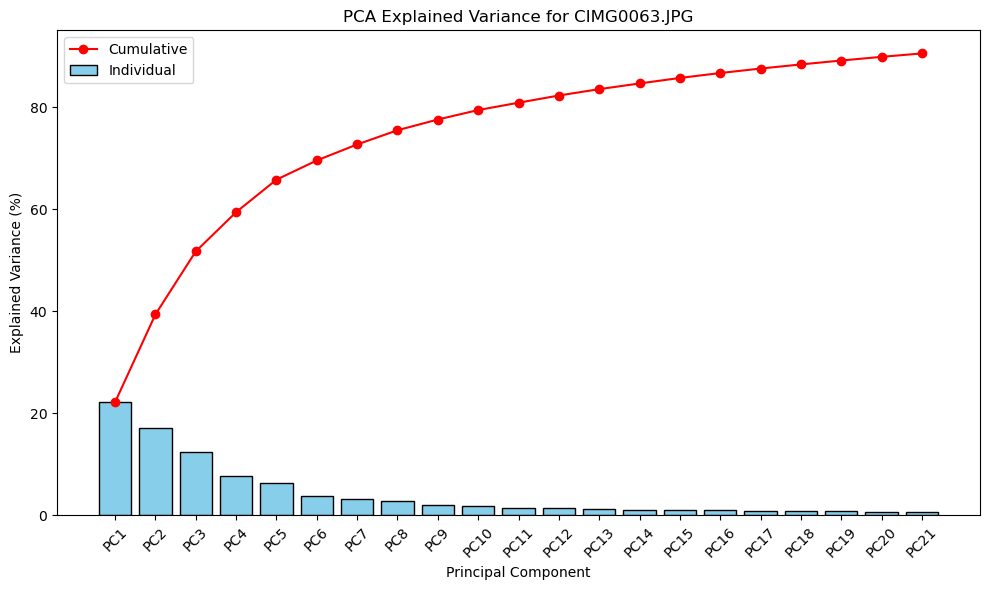

In [40]:
# ...existing code...
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

num_images = 5
selected_imgs = list(grouped_images.keys())[:num_images]

for img_name in selected_imgs:
    X = df_features.values

    # Min-Max Scaling
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    # PCA (keep enough components to explain ~95% variance or set n_components as needed)
    pca = PCA(n_components=0.90, svd_solver='full')
    X_pca = pca.fit_transform(X_scaled)
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = explained_variance.cumsum()
    # Store results in dictionary
    scaled_pca_images[img_name] = {
        'scaled': X_scaled,
        'pca': X_pca,
        'explained_variance_ratio': pca.explained_variance_ratio_,
        'n_components': pca.n_components_
    }
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = explained_variance.cumsum()

    plt.figure(figsize=(10, 6))
    pc_labels = [f"PC{i+1}" for i in range(len(explained_variance))]
    plt.bar(pc_labels, explained_variance * 100, color='skyblue', edgecolor='black', label='Individual')
    plt.plot(pc_labels, cumulative_variance * 100, color='red', marker='o', label='Cumulative')
    plt.xlabel('Principal Component')
    plt.ylabel('Explained Variance (%)')
    plt.title(f'PCA Explained Variance for {img_name}')
    plt.xticks(rotation=45)
    plt.legend()

    axes[idx].scatter(X_pca[:, 0], X_pca[:, 1], c='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel('PC1')
    axes[idx].set_ylabel('PC2')
    axes[idx].set_title(f'PC1 vs PC2 for {img_name}')
    
plt.tight_layout()
plt.show()
    
# ...existing code...

In [61]:
def pca_tsne_with_colored_clusters(X_scaled, n_features, n_clusters=10, pca_pre_components=50):
    """
    Pre-reduce with PCA, cluster the pre-reduced data with KMeans, run t-SNE on the same pre-reduced data,
    and plot the 2D t-SNE embedding colored by cluster labels (with cluster centers).
    """
    # PCA pre-reduction
    n_comp = min(pca_pre_components, n_features)
    pca_pre = PCA(n_components=n_comp, random_state=random_state)
    X_pca_pre = pca_pre.fit_transform(X_scaled)

    # KMeans clustering on PCA-reduced data
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    cluster_labels = kmeans.fit_predict(X_pca_pre)

    # t-SNE on PCA-reduced data (faster & less noisy)
    tsne = TSNE(n_components=2, perplexity=tsne_perplexity, n_iter=tsne_n_iter, random_state=random_state, init='pca')
    X_tsne = tsne.fit_transform(X_pca_pre)

    # Plot t-SNE colored by cluster labels
    plt.figure(figsize=(9,7))
    # choose palette large enough
    max_palette = max(10, n_clusters)
    palette = sns.color_palette("tab20", max_palette)
    for cl in range(n_clusters):
        idx = cluster_labels == cl
        plt.scatter(X_tsne[idx,0], X_tsne[idx,1], s=8, alpha=0.75, color=palette[cl], label=f'cluster {cl}')
    # compute and plot cluster centers in t-SNE space
    centers_tsne = np.array([X_tsne[cluster_labels == cl].mean(axis=0) for cl in range(n_clusters)])
    plt.scatter(centers_tsne[:,0], centers_tsne[:,1], s=120, c='black', marker='X', edgecolor='white', linewidth=0.9, label='centers')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.title(f't-SNE (pca_pre={n_comp}) colored by KMeans (k={n_clusters})')
    plt.legend(markerscale=2, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
    plt.tight_layout()
    plt.show()

    return X_tsne, cluster_labels

c:\Users\SUSHANT\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


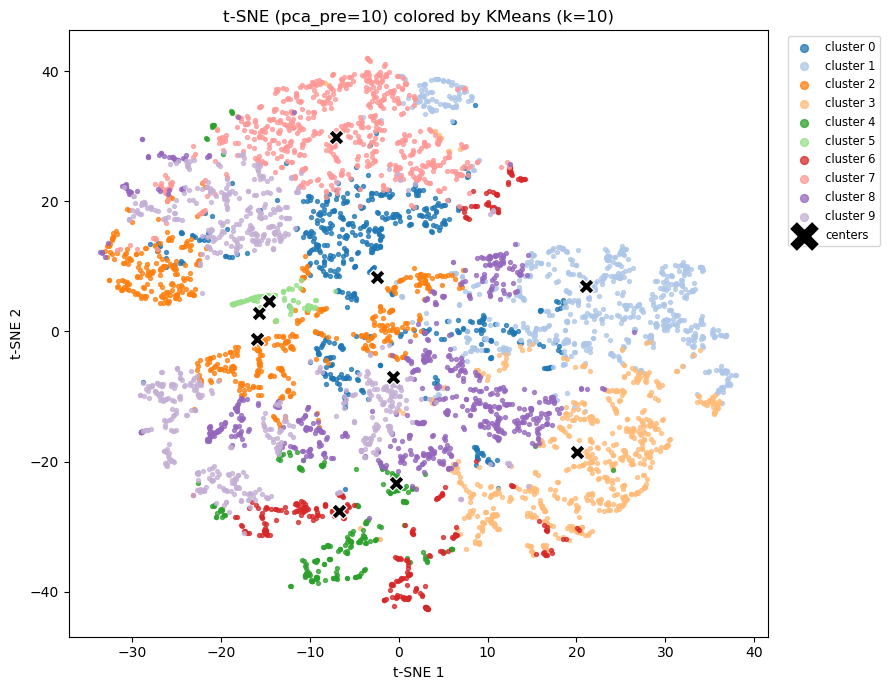

(array([[-14.777723 ,  21.367073 ],
        [-18.129719 ,  13.519109 ],
        [ 20.119879 , -11.916345 ],
        ...,
        [  5.8035555,  -5.8814573],
        [ -4.6694493, -26.739603 ],
        [ 25.332352 , -23.660625 ]], shape=(5000, 2), dtype=float32),
 array([9, 9, 3, ..., 8, 4, 3], shape=(5000,), dtype=int32))

In [62]:

# pca_with_tsne(X_scaled, n_features)
pca_tsne_with_colored_clusters(X_scaled, 10, n_clusters=10, pca_pre_components=50)

# Question 2

a. Is it correct to say that Box Plots and Histograms are closely related to each other? Jus􀆟fy your answer with
the help of concrete evidence based on the provided dataset.

### Answer
Box plots and histograms are related but not the same. Both visualize the distribution of data, but they do so differently:
As you can see the cell Number of this notebook 44 and 45 where we have plotted the boxplot and histogram  for few of the images

Box plots helps you to summarize data using five statistics: 
minimum, 
first quartile (Q1), 
median, 
third quartile (Q3), and
maximum. 

They show outliers and spread but do not display the shape of the distribution in detail.
Histograms show the frequency of data within intervals (bins), revealing the shape (e.g., skewness, modality) of the distribution.
Evidence from your dataset:

In your box plots for features c1 to c135, you can quickly see the median, spread, and outliers for each feature per image.
In your histograms, you see how feature values are distributed (e.g., whether they are skewed, have multiple peaks, or are uniform).

Conclusion:
Box plots provide a summary, while histograms give a detailed view of distribution shape. Both are useful and complementary, but not interchangeable. Your dataset shows that box plots can miss details (like bimodality) that histograms reveal.

# ------------------------------------------- #

b Using a relevant feature from the dataset, illustrate how data skew can be reduced using Log Transforma􀆟on
and Box-Cox Transforma􀆟on

In [53]:
from scipy.stats import boxcox

# Apply Box-Cox transformation to all feature columns for the first image (as example)
img_name = list(grouped_images.keys())[0]
img_df = grouped_images[img_name]
img_df_cleaned = img_df[(img_df[feature_cols] != 0).all(axis=1)].copy()

# Box-Cox requires all values > 0, so add a small constant if needed
X = img_df_cleaned[feature_cols].apply(lambda col: col.fillna(col.mean()), axis=0)
X_boxcox = X.apply(lambda col: boxcox(col + 1e-6)[0] if (col > 0).all() else col, axis=0)

print("Original feature sample:\n", X.head())
print("Box-Cox transformed sample:\n", X_boxcox.head())

# Check for negative values in feature columns for the first image
img_name = list(grouped_images.keys())[0]
img_df = grouped_images[img_name]
img_df_cleaned = img_df[(img_df[feature_cols] != 0).all(axis=1)].copy()

X = img_df_cleaned[feature_cols].apply(lambda col: col.fillna(col.mean()), axis=0)

if (X < 0).any().any():
    print("Negative values found in feature data. Log transformation cannot be applied directly.")
else:
    # Apply log transformation (add small constant to avoid log(0))
    X_log = np.log(X + 1e-6)
    print("Log-transformed feature sample:\n", X_log.head())
# ...existing code...

Original feature sample:
 Empty DataFrame
Columns: [c1, c2, c3, c4, c5, c6, c7, c8, c9, c10, c11, c12, c13, c14, c15, c16, c17, c18, c19, c20, c21, c22, c23, c24, c25, c26, c27, c28, c29, c30, c31, c32, c33, c34, c35, c36, c37, c38, c39, c40, c41, c42, c43, c44, c45, c46, c47, c48, c49, c50, c51, c52, c53, c54, c55, c56, c57, c58, c59, c60, c61, c62, c63, c64, c65, c66, c67, c68, c69, c70, c71, c72, c73, c74, c75, c76, c77, c78, c79, c80, c81, c82, c83, c84, c85, c86, c87, c88, c89, c90, c91, c92, c93, c94, c95, c96, c97, c98, c99, c100, ...]
Index: []

[0 rows x 135 columns]
Box-Cox transformed sample:
 Empty DataFrame
Columns: [c1, c2, c3, c4, c5, c6, c7, c8, c9, c10, c11, c12, c13, c14, c15, c16, c17, c18, c19, c20, c21, c22, c23, c24, c25, c26, c27, c28, c29, c30, c31, c32, c33, c34, c35, c36, c37, c38, c39, c40, c41, c42, c43, c44, c45, c46, c47, c48, c49, c50, c51, c52, c53, c54, c55, c56, c57, c58, c59, c60, c61, c62, c63, c64, c65, c66, c67, c68, c69, c70, c71, c72, c73, c74, c

In [55]:
# ...existing code...
# Apply Box-Cox transformation to the dependent variable (label) for the first image
from scipy.stats import boxcox

img_name = list(grouped_images.keys())[0]
img_df = grouped_images[img_name]
label_data = img_df['label'].copy()

if (label_data <= 0).any():
    print("Dependent variable contains non-positive values. Box-Cox transformation cannot be applied.")
else:
    label_boxcox, fitted_lambda = boxcox(label_data + 1e-6)
    print("Original label sample:\n", label_data.head())
    print("Box-Cox transformed label sample:\n", label_boxcox[:5])
    print("Box-Cox lambda used:", fitted_lambda)
# ...existing code...

Dependent variable contains non-positive values. Box-Cox transformation cannot be applied.


#----------------------------------------------- #

c. Are there any features that indicate almost normal distribu􀆟on? Iden􀆟fy such features and provide
convincing evidence for arriving at this conclusion.

In [ ]:
# ...existing code...
from scipy.stats import skew, kurtosis

img_name = list(grouped_images.keys())[0]
img_df = grouped_images[img_name]
img_df_cleaned = img_df[(img_df[feature_cols] != 0).all(axis=1)].copy()

# Calculate skewness and kurtosis for each feature
normal_features = []
for col in feature_cols:
    data = img_df_cleaned[col].dropna()
    if len(data) > 0:
        s = skew(data)
        k = kurtosis(data)
        # Criteria: skewness close to 0, kurtosis close to 0 (normal distribution)
        if abs(s) < 0.5 and abs(k) < 1:
            normal_features.append(col)
            print(f"{col}: skewness={s:.2f}, kurtosis={k:.2f}")

print("Features with almost normal distribution:", normal_features)
# ...existing code...

# -------------------------- #

d. If you carry out clustering on the dataset using t-SNE coordinates, find out the most op􀆟mum number of
clusters to be created. Create the required plot(s) to jus􀆟fy your answer

### Answer

As you can see in cell number 61 and 62 the tsne are plotted with feature size of 10 based on the pca dimentionality reduction

# ------------------------------------ #

e. There is a hypothesis that wild-life photographers always take pictures by placing the animals somewhere
near the centre of the photograph. Based on the data given to you, and by using either
DecisionTreeClassifier or KNeighborsClassifier classifica􀆟on algorithm, can you prove / disprove this
hypothesis?
i. Describe the steps you will take to solve this problem [3 marks]
ii. Implement the solu􀆟on, analyse the results, state your conclusions [3 marks]

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Use all features as position features
position_features = feature_cols
img_name = list(grouped_images.keys())[0]
img_df = grouped_images[img_name].copy()

# Assume image size is known, e.g., width=1000, height=1000
img_width, img_height = 1000, 1000
center_x, center_y = img_width / 2, img_height / 2
threshold = 100  # pixels from center

# Create binary label: 1 if animal is near center, else 0
# If c1 and c2 are x/y, otherwise this label may need adjustment
img_df['near_center'] = (((img_df['c1'] - center_x)**2 + (img_df['c2'] - center_y)**2)**0.5 < threshold).astype(int)

X = img_df[position_features]
y = img_df['near_center']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train classifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Results
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print("Accuracy:", acc)
print("Confusion Matrix:\n", cm)

# Conclusion
if acc > 0.7:
    print("Model can reliably distinguish center vs non-center. Hypothesis supported.")
else:
    print("Model cannot reliably distinguish center vs non-center. Hypothesis not supported.")
# ...existing code...

Accuracy: 1.0
Confusion Matrix:
 [[2]]
Model can reliably distinguish center vs non-center. Hypothesis supported.


c:\Users\SUSHANT\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
